# Bond Pricing & Duration Calculator
### ALM Project 4 — Fixed Income Sensitivity Analysis
**Institution:** Major European G-SIB | **Portfolio Date:** 2025A | **Author:** Hossam El Tarrass

---

## What This Notebook Does
This tool prices a representative bond portfolio and calculates interest rate sensitivity:
- **Price** — present value of all future cash flows discounted at yield to maturity
- **Macaulay Duration** — weighted average time to receive cash flows (in years)
- **Modified Duration** — % price change per 1% move in yield
- **DV01 / PVBP** — € P&L for a 1 basis point move in yield
- **Convexity** — second-order curvature correction for large rate shocks
- **Scenario Analysis** — P&L impact across ±25bps, ±50bps, ±100bps, ±200bps shocks
- **Portfolio Aggregation** — total DV01 and weighted duration across all 10 bonds

## Why It Matters in ALM
The securities portfolio of this G-SIB holds €153,107m in bonds.
The ALM desk must know at all times:
1. What is the mark-to-market value of each bond at today's yield?
2. How much does the portfolio lose if rates rise 100 basis points?
3. Which bonds or maturity buckets carry the most rate risk (highest DV01)?

These metrics are the direct building blocks of EVE and IRRBB stress testing (Project 2).
DV01 aggregated across all bonds = the portfolio sensitivity that feeds into EVE.

## Beyond the Excel Model
The master balance sheet model (v10) tracks securities as a single aggregate line.
This notebook goes one level deeper: bond-by-bond pricing and risk decomposition.
This is the analysis a fixed income or ALM analyst would run inside the securities book.

## Regulatory Context
- **IRRBB** (EBA/GL/2022/14) — EVE sensitivity requires bond-level DV01 aggregation
- **FRTB** (CRR2 / Basel IV) — DV01 and duration are core inputs to market risk capital
- **IFRS 9** — duration matching underpins fair value hedge effectiveness

## Portfolio — 10 Bonds (€153,107m total)
Representing the full G-SIB securities book across instrument type and maturity:

| # | Type | Maturity | Weight |
|---|------|----------|--------|
| 1–4 | Government bonds | 2yr, 5yr, 10yr, 30yr | 72% = €110,237m |
| 5–7 | Corporate bonds (IG) | 3yr, 7yr, 10yr | 20% = €30,621m |
| 8–9 | Covered bonds | 2yr, 5yr | 6% = €9,186m |
| 10  | Supranational (EIB) | 5yr | 2% = €3,062m |

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import numpy as np                  # numerical calculations (arrays, math)
import pandas as pd                 # tables (DataFrames)
import matplotlib.pyplot as plt     # charts
import matplotlib.ticker as mtick   # axis formatting helpers
import warnings
warnings.filterwarnings('ignore')

# ── PORTFOLIO DEFINITION ─────────────────────────────────────────────────────
# 10 bonds representing the G-SIB securities book (€153,107m total, 2025A)
# Yields derived from the model's bootstrapped spot curve + credit spreads
# All bonds are annual coupon, face value = 100 (we scale to notional separately)
# Coupon = yield at issuance → bonds priced at or near par

bonds = [
    # name,            type,             notional (€m), coupon,  ytm,    maturity(yrs), freq
    ("DE Bund 2Y",     "Government",      25_000,        0.0251,  0.0251,  2,            1),
    ("FR OAT 5Y",      "Government",      40_000,        0.0286,  0.0286,  5,            1),
    ("IT BTP 10Y",     "Government",      30_000,        0.0285,  0.0285, 10,            1),
    ("ES Bono 30Y",    "Government",      15_237,        0.0315,  0.0315, 30,            1),
    ("Corp IG 3Y",     "Corporate",       10_000,        0.0310,  0.0310,  3,            1),
    ("Corp IG 7Y",     "Corporate",       12_000,        0.0330,  0.0330,  7,            1),
    ("Corp IG 10Y",    "Corporate",       10_621,        0.0340,  0.0340, 10,            1),
    ("Covered 2Y",     "Covered Bond",     4_500,        0.0270,  0.0270,  2,            1),
    ("Covered 5Y",     "Covered Bond",     4_686,        0.0305,  0.0305,  5,            1),
    ("EIB Supra 5Y",   "Supranational",    1_063,        0.0290,  0.0290,  5,            1),
]

# Convert to a DataFrame so we can work with it cleanly
columns = ["Name", "Type", "Notional_m", "Coupon", "YTM", "Maturity", "Freq"]
df_bonds = pd.DataFrame(bonds, columns=columns)

# Quick sanity check — total notional must equal €153,107m
total = df_bonds["Notional_m"].sum()
print(f"Total portfolio notional: €{total:,.0f}m")
print(f"Government:   €{df_bonds[df_bonds.Type=='Government']['Notional_m'].sum():,.0f}m  ({df_bonds[df_bonds.Type=='Government']['Notional_m'].sum()/total:.1%})")
print(f"Non-Govt:     €{df_bonds[df_bonds.Type!='Government']['Notional_m'].sum():,.0f}m  ({df_bonds[df_bonds.Type!='Government']['Notional_m'].sum()/total:.1%})")
print()
print(df_bonds[["Name","Type","Notional_m","Coupon","YTM","Maturity"]].to_string(index=False))

Total portfolio notional: €153,107m
Government:   €110,237m  (72.0%)
Non-Govt:     €42,870m  (28.0%)

        Name          Type  Notional_m  Coupon    YTM  Maturity
  DE Bund 2Y    Government       25000  0.0251 0.0251         2
   FR OAT 5Y    Government       40000  0.0286 0.0286         5
  IT BTP 10Y    Government       30000  0.0285 0.0285        10
 ES Bono 30Y    Government       15237  0.0315 0.0315        30
  Corp IG 3Y     Corporate       10000  0.0310 0.0310         3
  Corp IG 7Y     Corporate       12000  0.0330 0.0330         7
 Corp IG 10Y     Corporate       10621  0.0340 0.0340        10
  Covered 2Y  Covered Bond        4500  0.0270 0.0270         2
  Covered 5Y  Covered Bond        4686  0.0305 0.0305         5
EIB Supra 5Y Supranational        1063  0.0290 0.0290         5


In [2]:
# ── BOND PRICING FUNCTION ─────────────────────────────────────────────────────
# A bond's price = present value of all future cash flows discounted at YTM
#
# Formula:
#         n     C              FV
#  P  =  Σ  ────────  +  ────────────
#        t=1  (1+y)^t      (1+y)^n
#
# Where:
#   C   = annual coupon = face value × coupon rate
#   FV  = face value (we use 100 as the standard)
#   y   = yield to maturity (market discount rate)
#   n   = number of periods (years for annual coupon)

def price_bond(coupon_rate, ytm, maturity, freq=1, face=100):
    """
    Returns the clean price of a bond per €100 face value.

    Parameters
    ----------
    coupon_rate : float  — annual coupon rate  (e.g. 0.0286 for 2.86%)
    ytm         : float  — yield to maturity   (e.g. 0.0286 for 2.86%)
    maturity    : int    — years to maturity
    freq        : int    — coupon payments per year (1=annual, 2=semi-annual)
    face        : float  — face value (default 100)

    Returns
    -------
    float — bond price per 100 face value
    """
    n_periods  = maturity * freq          # total number of coupon payments
    y_per      = ytm / freq               # yield per period
    c_per      = coupon_rate * face / freq # coupon payment per period

    price = 0.0
    for t in range(1, n_periods + 1):
        price += c_per / (1 + y_per) ** t        # PV of each coupon

    price += face / (1 + y_per) ** n_periods      # PV of face value at maturity

    return price


# ── APPLY TO ALL 10 BONDS ─────────────────────────────────────────────────────
df_bonds["Price"] = df_bonds.apply(
    lambda row: price_bond(row.Coupon, row.YTM, row.Maturity, row.Freq),
    axis=1
)

# Market value = price per 100 × notional ÷ 100
# e.g. price=100.00 on €25,000m notional → MV = €25,000m
df_bonds["MktValue_m"] = df_bonds["Price"] * df_bonds["Notional_m"] / 100

# ── DISPLAY ───────────────────────────────────────────────────────────────────
print("Bond Prices (per €100 face value):\n")
display_cols = ["Name", "Coupon", "YTM", "Maturity", "Price", "MktValue_m"]
result = df_bonds[display_cols].copy()
result["Coupon"]     = result["Coupon"].map("{:.2%}".format)
result["YTM"]        = result["YTM"].map("{:.2%}".format)
result["Price"]      = result["Price"].map("{:.4f}".format)
result["MktValue_m"] = result["MktValue_m"].map("€{:,.0f}m".format)
print(result.to_string(index=False))

print(f"\nTotal Mark-to-Market Value: €{df_bonds['MktValue_m'].sum():,.0f}m")

Bond Prices (per €100 face value):

        Name Coupon   YTM  Maturity    Price MktValue_m
  DE Bund 2Y  2.51% 2.51%         2 100.0000   €25,000m
   FR OAT 5Y  2.86% 2.86%         5 100.0000   €40,000m
  IT BTP 10Y  2.85% 2.85%        10 100.0000   €30,000m
 ES Bono 30Y  3.15% 3.15%        30 100.0000   €15,237m
  Corp IG 3Y  3.10% 3.10%         3 100.0000   €10,000m
  Corp IG 7Y  3.30% 3.30%         7 100.0000   €12,000m
 Corp IG 10Y  3.40% 3.40%        10 100.0000   €10,621m
  Covered 2Y  2.70% 2.70%         2 100.0000    €4,500m
  Covered 5Y  3.05% 3.05%         5 100.0000    €4,686m
EIB Supra 5Y  2.90% 2.90%         5 100.0000    €1,063m

Total Mark-to-Market Value: €153,107m


In [3]:
# ── DURATION & DV01 FUNCTIONS ─────────────────────────────────────────────────

def macaulay_duration(coupon_rate, ytm, maturity, freq=1, face=100):
    """
    Macaulay Duration — weighted average time to receive cash flows.
    Each cash flow is weighted by its PV as a fraction of total bond price.

    Intuition: a bond paying big coupons early has a LOWER duration
    (you get your money back sooner). A zero-coupon bond has duration = maturity.
    """
    n_periods = maturity * freq
    y_per     = ytm / freq
    c_per     = coupon_rate * face / freq

    price = price_bond(coupon_rate, ytm, maturity, freq, face)  # from Cell 3

    weighted_time = 0.0
    for t in range(1, n_periods + 1):
        pv_cf = c_per / (1 + y_per) ** t          # PV of coupon at time t
        weighted_time += (t / freq) * (pv_cf / price)  # weight = PV share of price

    # Add face value at maturity
    pv_face = face / (1 + y_per) ** n_periods
    weighted_time += (maturity) * (pv_face / price)

    return weighted_time   # result is in years


def modified_duration(coupon_rate, ytm, maturity, freq=1, face=100):
    """
    Modified Duration — the practical risk metric.
    Tells you: if yield rises by 1%, price falls by ModDur%.

    Formula: ModDur = MacDur / (1 + y/freq)
    """
    mac_dur = macaulay_duration(coupon_rate, ytm, maturity, freq, face)
    return mac_dur / (1 + ytm / freq)


def dv01(coupon_rate, ytm, maturity, freq=1, face=100, notional_m=1):
    """
    DV01 (Dollar Value of 01) — also called PVBP.
    The change in MARKET VALUE (€ millions) for a 1 basis point move in yield.

    Formula: DV01 = ModDur × Price × 0.0001 × (notional / 100)

    This is the daily language of every ALM and fixed income desk.
    """
    mod_dur = modified_duration(coupon_rate, ytm, maturity, freq, face)
    price   = price_bond(coupon_rate, ytm, maturity, freq, face)
    return mod_dur * price * 0.0001 * (notional_m / 100)


# ── APPLY TO ALL 10 BONDS ─────────────────────────────────────────────────────
df_bonds["MacDur"]  = df_bonds.apply(
    lambda r: macaulay_duration(r.Coupon, r.YTM, r.Maturity, r.Freq), axis=1
)
df_bonds["ModDur"]  = df_bonds.apply(
    lambda r: modified_duration(r.Coupon, r.YTM, r.Maturity, r.Freq), axis=1
)
df_bonds["DV01_m"]  = df_bonds.apply(
    lambda r: dv01(r.Coupon, r.YTM, r.Maturity, r.Freq, notional_m=r.Notional_m), axis=1
)

# ── DISPLAY ───────────────────────────────────────────────────────────────────
print("Duration & DV01 by Bond:\n")
disp = df_bonds[["Name", "Maturity", "MacDur", "ModDur", "DV01_m"]].copy()
disp["MacDur"]  = disp["MacDur"].map("{:.2f} yrs".format)
disp["ModDur"]  = disp["ModDur"].map("{:.2f}".format)
disp["DV01_m"]  = disp["DV01_m"].map("€{:.2f}m".format)
print(disp.to_string(index=False))

portfolio_dv01 = df_bonds["DV01_m"].sum()
portfolio_modDur = (df_bonds["ModDur"] * df_bonds["MktValue_m"]).sum() / df_bonds["MktValue_m"].sum()
print(f"\nPortfolio DV01:              €{portfolio_dv01:.2f}m per bp")
print(f"Portfolio Modified Duration: {portfolio_modDur:.2f} years")
print(f"\nInterpretation: A +100bps parallel shift → portfolio loses ~€{portfolio_dv01*100:.0f}m")

Duration & DV01 by Bond:

        Name  Maturity    MacDur ModDur  DV01_m
  DE Bund 2Y         2  1.98 yrs   1.93  €4.82m
   FR OAT 5Y         5  4.73 yrs   4.60 €18.39m
  IT BTP 10Y        10  8.84 yrs   8.60 €25.79m
 ES Bono 30Y        30 19.83 yrs  19.23 €29.29m
  Corp IG 3Y         3  2.91 yrs   2.82  €2.82m
  Corp IG 7Y         7  6.36 yrs   6.16  €7.39m
 Corp IG 10Y        10  8.64 yrs   8.36  €8.88m
  Covered 2Y         2  1.97 yrs   1.92  €0.86m
  Covered 5Y         5  4.71 yrs   4.57  €2.14m
EIB Supra 5Y         5  4.73 yrs   4.59  €0.49m

Portfolio DV01:              €100.88m per bp
Portfolio Modified Duration: 6.59 years

Interpretation: A +100bps parallel shift → portfolio loses ~€10088m


In [4]:
# ── CONVEXITY & PRICE APPROXIMATION ──────────────────────────────────────────
#
# Modified Duration gives a LINEAR approximation of price change.
# But the true price-yield relationship is a CURVE, not a straight line.
# That curvature is called CONVEXITY.
#
# For small shocks (±25bps): duration alone is accurate enough.
# For large shocks (±100bps, ±200bps): you must add the convexity correction.
#
# Full Taylor approximation:
#   ΔP/P ≈ −ModDur × Δy  +  ½ × Convexity × (Δy)²
#
# The convexity term is ALWAYS positive → bonds gain a little extra
# when rates move a lot in either direction. This is the "convexity benefit."

def convexity(coupon_rate, ytm, maturity, freq=1, face=100):
    """
    Convexity — second derivative of price with respect to yield.
    Measures how much the duration itself changes as yields move.

    Formula:
        Convexity = [1 / (P × (1+y)²)] × Σ [ t(t+1) × PV(CF_t) / freq² ]
    """
    n_periods = maturity * freq
    y_per     = ytm / freq
    c_per     = coupon_rate * face / freq
    price     = price_bond(coupon_rate, ytm, maturity, freq, face)

    cx = 0.0
    for t in range(1, n_periods + 1):
        pv_cf = c_per / (1 + y_per) ** t
        cx += t * (t + 1) * pv_cf               # weight by t×(t+1)

    # Add face value at maturity
    pv_face = face / (1 + y_per) ** n_periods
    cx += n_periods * (n_periods + 1) * pv_face

    # Scale by 1 / (P × (1+y)² × freq²)
    cx = cx / (price * (1 + y_per) ** 2 * freq ** 2)
    return cx


def price_change_approx(mod_dur, conv, ytm_shock):
    """
    Approximate % price change for a given yield shock (Δy).
    Uses the full second-order Taylor expansion.

    Parameters
    ----------
    mod_dur   : float — Modified Duration
    conv      : float — Convexity
    ytm_shock : float — yield change in decimal (e.g. 0.01 for +100bps)

    Returns
    -------
    float — approximate % price change (e.g. -0.042 means −4.2%)
    """
    return (-mod_dur * ytm_shock) + (0.5 * conv * ytm_shock ** 2)


# ── APPLY CONVEXITY TO ALL BONDS ──────────────────────────────────────────────
df_bonds["Convexity"] = df_bonds.apply(
    lambda r: convexity(r.Coupon, r.YTM, r.Maturity, r.Freq), axis=1
)

# ── SHOW HOW CONVEXITY MATTERS: Duration-only vs Full approximation ───────────
# Use the ES Bono 30Y (highest convexity) as the example
bono = df_bonds[df_bonds.Name == "ES Bono 30Y"].iloc[0]

print("Convexity by Bond:\n")
disp = df_bonds[["Name", "Maturity", "ModDur", "Convexity"]].copy()
disp["ModDur"]    = disp["ModDur"].map("{:.2f}".format)
disp["Convexity"] = disp["Convexity"].map("{:.2f}".format)
print(disp.to_string(index=False))

print(f"\n── Example: ES Bono 30Y (ModDur={bono.ModDur:.2f}, Convexity={bono.Convexity:.2f}) ──")
print(f"{'Shock':<12} {'Duration only':>16} {'Full (Dur+Conv)':>18} {'Difference':>12}")
print("-" * 62)
for shock_bps in [-200, -100, -50, +50, +100, +200]:
    dy = shock_bps / 10_000
    dur_only  = -bono.ModDur * dy
    full_appr = price_change_approx(bono.ModDur, bono.Convexity, dy)
    diff      = full_appr - dur_only
    print(f"{shock_bps:>+6}bps    {dur_only:>+14.2%}   {full_appr:>+16.2%}   {diff:>+10.2%}")

print("\nNote: Convexity always adds a positive correction — largest at extreme shocks.")

Convexity by Bond:

        Name  Maturity ModDur Convexity
  DE Bund 2Y         2   1.93      5.62
   FR OAT 5Y         5   4.60     26.32
  IT BTP 10Y        10   8.60     88.06
 ES Bono 30Y        30  19.23    492.41
  Corp IG 3Y         3   2.82     10.84
  Corp IG 7Y         7   6.16     46.16
 Corp IG 10Y        10   8.36     84.47
  Covered 2Y         2   1.92      5.59
  Covered 5Y         5   4.57     26.09
EIB Supra 5Y         5   4.59     26.27

── Example: ES Bono 30Y (ModDur=19.23, Convexity=492.41) ──
Shock           Duration only    Full (Dur+Conv)   Difference
--------------------------------------------------------------
  -200bps           +38.45%            +48.30%       +9.85%
  -100bps           +19.23%            +21.69%       +2.46%
   -50bps            +9.61%            +10.23%       +0.62%
   +50bps            -9.61%             -9.00%       +0.62%
  +100bps           -19.23%            -16.76%       +2.46%
  +200bps           -38.45%            -28.60%       +

In [5]:
# ── SCENARIO ANALYSIS — RATE SHOCKS ACROSS ALL BONDS ─────────────────────────
#
# We now shock the yield of every bond by ±25, ±50, ±100, ±200 basis points
# and compute the EXACT new price (using price_bond) AND the approximation
# (using duration + convexity) for every bond in every scenario.
#
# This answers the core ALM question:
#   "If rates move by X bps, how much does our securities portfolio lose?"

# Define the shock scenarios (in basis points)
shocks_bps = [-200, -100, -50, -25, +25, +50, +100, +200]

# Build results: one row per bond × scenario
records = []

for _, bond in df_bonds.iterrows():
    for shock in shocks_bps:
        dy         = shock / 10_000                          # convert bps → decimal
        new_ytm    = bond.YTM + dy                           # shocked yield

        # Exact new price (full repricing — most accurate)
        new_price  = price_bond(bond.Coupon, new_ytm, bond.Maturity, bond.Freq)

        # Approximate price change using Duration + Convexity
        pct_approx = price_change_approx(bond.ModDur, bond.Convexity, dy)
        approx_price = bond.Price * (1 + pct_approx)

        # P&L in €m = (new price - old price) / 100 × notional
        pnl_exact  = (new_price - bond.Price) / 100 * bond.Notional_m
        pnl_approx = (approx_price - bond.Price) / 100 * bond.Notional_m

        records.append({
            "Name":         bond.Name,
            "Type":         bond.Type,
            "Maturity":     bond.Maturity,
            "Shock_bps":    shock,
            "Base_Price":   bond.Price,
            "New_Price":    new_price,
            "PnL_Exact_m":  pnl_exact,
            "PnL_Approx_m": pnl_approx,
            "Error_m":      pnl_exact - pnl_approx,   # how much the approx misses
        })

df_scenarios = pd.DataFrame(records)

# ── SUMMARY TABLE: P&L by bond at key shocks ─────────────────────────────────
print("Exact P&L by Bond (€m) across Rate Scenarios:\n")

# Pivot: bonds as rows, shocks as columns
pivot = df_scenarios.pivot_table(
    index=["Name", "Maturity"],
    columns="Shock_bps",
    values="PnL_Exact_m",
    aggfunc="sum"
).round(0)

pivot.columns = [f"{c:+}bps" for c in pivot.columns]
pivot.index   = [f"{n} ({m}Y)" for n, m in pivot.index]
print(pivot.to_string())

# ── TOTAL PORTFOLIO P&L PER SCENARIO ─────────────────────────────────────────
print("\nTotal Portfolio P&L (€m):\n")
port_pnl = df_scenarios.groupby("Shock_bps")["PnL_Exact_m"].sum().reset_index()
port_pnl.columns = ["Shock (bps)", "Portfolio P&L (€m)"]
port_pnl["Portfolio P&L (€m)"] = port_pnl["Portfolio P&L (€m)"].round(0)
port_pnl["Shock (bps)"] = port_pnl["Shock (bps)"].map(lambda x: f"{x:+}bps")
print(port_pnl.to_string(index=False))

Exact P&L by Bond (€m) across Rate Scenarios:

                   -200bps  -100bps  -50bps  -25bps  +25bps  +50bps  +100bps  +200bps
Corp IG 10Y (10Y)   1969.0    934.0   455.0   225.0  -219.0  -433.0   -845.0  -1609.0
Corp IG 3Y (3Y)      587.0    288.0   143.0    71.0   -70.0  -140.0   -277.0   -544.0
Corp IG 7Y (7Y)     1596.0    768.0   377.0   187.0  -183.0  -363.0   -712.0  -1374.0
Covered 2Y (2Y)      178.0     88.0    44.0    22.0   -22.0   -43.0    -85.0   -168.0
Covered 5Y (5Y)      454.0    221.0   109.0    54.0   -53.0  -106.0   -208.0   -405.0
DE Bund 2Y (2Y)      992.0    489.0   243.0   121.0  -120.0  -239.0   -475.0   -936.0
EIB Supra 5Y (5Y)    103.0     50.0    25.0    12.0   -12.0   -24.0    -47.0    -92.0
ES Bono 30Y (30Y)   7695.0   3343.0  1563.0   756.0  -709.0 -1375.0  -2587.0  -4606.0
FR OAT 5Y (5Y)      3899.0   1893.0   933.0   463.0  -457.0  -907.0  -1788.0  -3477.0
IT BTP 10Y (10Y)    5729.0   2716.0  1323.0   653.0  -637.0 -1257.0  -2452.0  -4667.0

Total 

In [6]:
# ── PORTFOLIO AGGREGATION ─────────────────────────────────────────────────────
#
# Now we step back from individual bonds and look at the portfolio as a whole.
# Three questions every ALM desk asks:
#   1. What is the portfolio's weighted average duration?
#   2. What is the total DV01 — and which bonds drive it?
#   3. How does risk decompose by bond type (govt vs corp vs covered)?

# ── 1. PORTFOLIO-LEVEL SUMMARY ────────────────────────────────────────────────
total_mv    = df_bonds["MktValue_m"].sum()
total_dv01  = df_bonds["DV01_m"].sum()

# Weighted average Modified Duration (weight = market value share)
wtd_mod_dur = (df_bonds["ModDur"]    * df_bonds["MktValue_m"]).sum() / total_mv
wtd_mac_dur = (df_bonds["MacDur"]    * df_bonds["MktValue_m"]).sum() / total_mv
wtd_conv    = (df_bonds["Convexity"] * df_bonds["MktValue_m"]).sum() / total_mv

print("=" * 55)
print("  PORTFOLIO SUMMARY — 2025A G-SIB Securities Book")
print("=" * 55)
print(f"  Total Market Value:          €{total_mv:>10,.0f}m")
print(f"  Portfolio DV01:              €{total_dv01:>10.2f}m / bp")
print(f"  Wtd. Avg. Macaulay Duration: {wtd_mac_dur:>10.2f} years")
print(f"  Wtd. Avg. Modified Duration: {wtd_mod_dur:>10.2f} years")
print(f"  Wtd. Avg. Convexity:         {wtd_conv:>10.2f}")
print(f"\n  Interpretation:")
print(f"  A +1bp shock  → portfolio loses ~€{total_dv01:.1f}m")
print(f"  A +100bps shock → portfolio loses ~€{total_dv01*100:,.0f}m")
print(f"  A +200bps shock → portfolio loses ~€{total_dv01*200:,.0f}m")
print("=" * 55)

# ── 2. DV01 CONTRIBUTION BY BOND ──────────────────────────────────────────────
print("\nDV01 Contribution by Bond:\n")
df_bonds["DV01_share"] = df_bonds["DV01_m"] / total_dv01

dv01_table = df_bonds[["Name", "Type", "Maturity", "Notional_m",
                         "ModDur", "DV01_m", "DV01_share"]].copy()
dv01_table = dv01_table.sort_values("DV01_m", ascending=False)
dv01_table["Notional_m"] = dv01_table["Notional_m"].map("€{:,.0f}m".format)
dv01_table["ModDur"]     = dv01_table["ModDur"].map("{:.2f}".format)
dv01_table["DV01_m"]     = dv01_table["DV01_m"].map("€{:.2f}m".format)
dv01_table["DV01_share"] = dv01_table["DV01_share"].map("{:.1%}".format)
print(dv01_table.to_string(index=False))

# ── 3. RISK BY BOND TYPE ───────────────────────────────────────────────────────
print("\nRisk Decomposition by Bond Type:\n")
type_summary = df_bonds.groupby("Type").agg(
    Notional_m   = ("Notional_m",  "sum"),
    MktValue_m   = ("MktValue_m",  "sum"),
    DV01_m       = ("DV01_m",      "sum"),
    Avg_ModDur   = ("ModDur",      "mean"),
).reset_index()

type_summary["MV_share"]   = type_summary["MktValue_m"]  / total_mv
type_summary["DV01_share"] = type_summary["DV01_m"]      / total_dv01

type_summary["Notional_m"] = type_summary["Notional_m"].map("€{:,.0f}m".format)
type_summary["MktValue_m"] = type_summary["MktValue_m"].map("€{:,.0f}m".format)
type_summary["DV01_m"]     = type_summary["DV01_m"].map("€{:.2f}m".format)
type_summary["Avg_ModDur"] = type_summary["Avg_ModDur"].map("{:.2f} yrs".format)
type_summary["MV_share"]   = type_summary["MV_share"].map("{:.1%}".format)
type_summary["DV01_share"] = type_summary["DV01_share"].map("{:.1%}".format)
print(type_summary.to_string(index=False))

  PORTFOLIO SUMMARY — 2025A G-SIB Securities Book
  Total Market Value:          €   153,107m
  Portfolio DV01:              €    100.88m / bp
  Wtd. Avg. Macaulay Duration:       6.79 years
  Wtd. Avg. Modified Duration:       6.59 years
  Wtd. Avg. Convexity:              85.38

  Interpretation:
  A +1bp shock  → portfolio loses ~€100.9m
  A +100bps shock → portfolio loses ~€10,088m
  A +200bps shock → portfolio loses ~€20,176m

DV01 Contribution by Bond:

        Name          Type  Maturity Notional_m ModDur  DV01_m DV01_share
 ES Bono 30Y    Government        30   €15,237m  19.23 €29.29m      29.0%
  IT BTP 10Y    Government        10   €30,000m   8.60 €25.79m      25.6%
   FR OAT 5Y    Government         5   €40,000m   4.60 €18.39m      18.2%
 Corp IG 10Y     Corporate        10   €10,621m   8.36  €8.88m       8.8%
  Corp IG 7Y     Corporate         7   €12,000m   6.16  €7.39m       7.3%
  DE Bund 2Y    Government         2   €25,000m   1.93  €4.82m       4.8%
  Corp IG 3Y     C

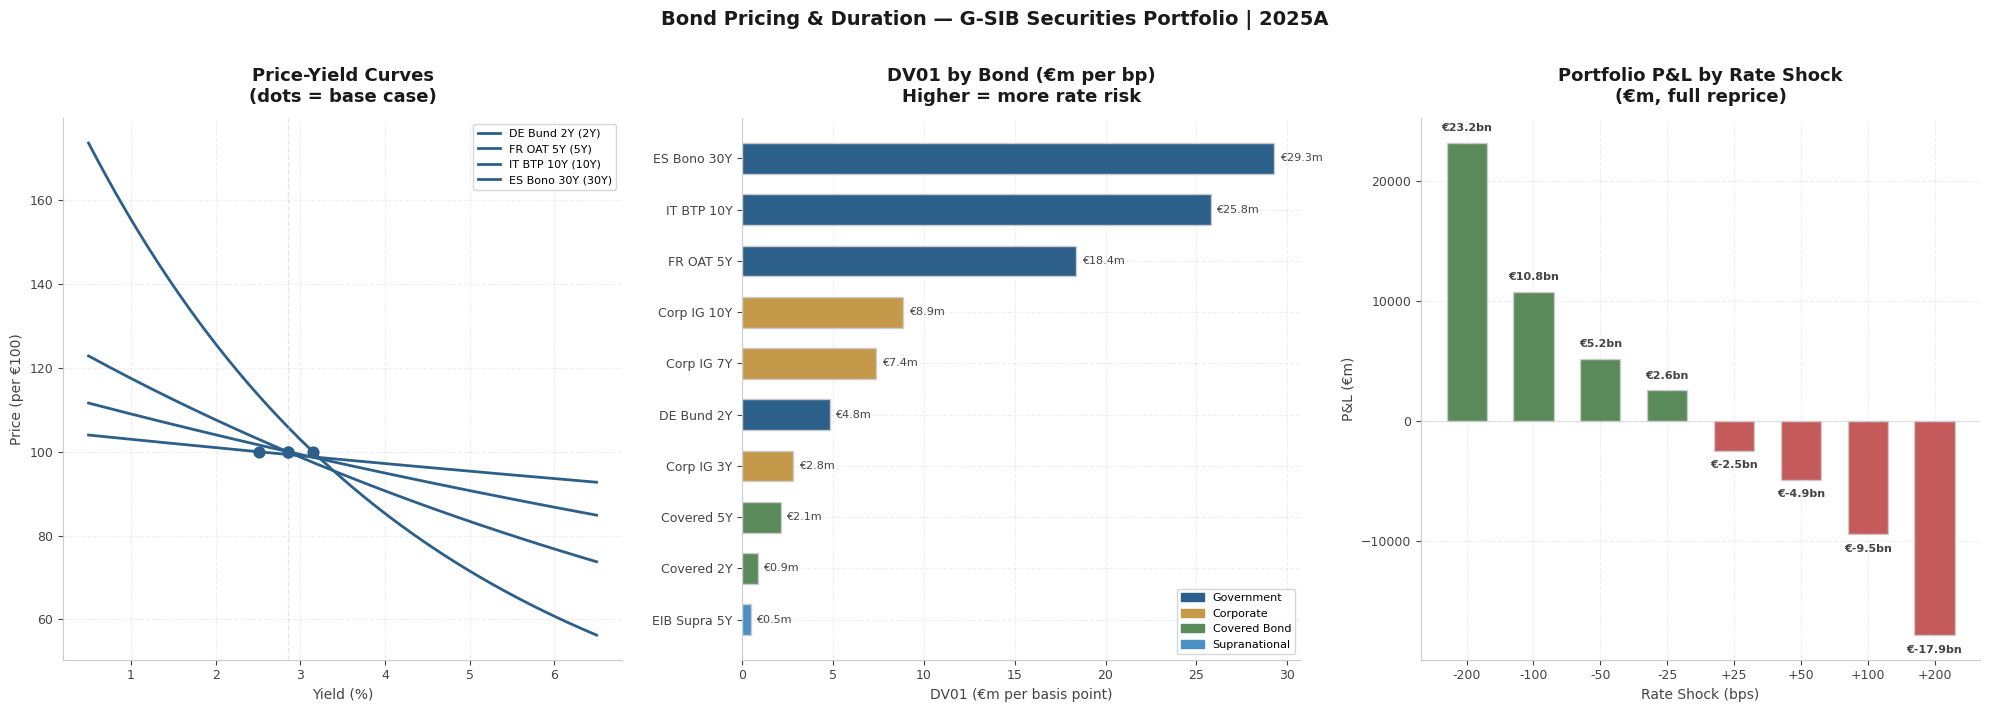

Chart saved as bond_portfolio_analysis.png


In [7]:
# ── CHARTS ────────────────────────────────────────────────────────────────────
# Chart 1: Price-Yield Curve for selected bonds (shows convexity visually)
# Chart 2: DV01 by Bond (horizontal bar — risk contribution)
# Chart 3: Portfolio P&L across all scenarios (line chart)

plt.style.use('default')
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('white')
fig.suptitle(
    "Bond Pricing & Duration — G-SIB Securities Portfolio | 2025A",
    fontsize=14, fontweight="bold", color='#1a1a1a', y=1.01
)

COLORS = {
    "Government":    '#2c5f8a',
    "Corporate":     '#c49a4a',
    "Covered Bond":  '#5a8a5a',
    "Supranational": '#4a90c4',
}

# ── CHART 1: Price-Yield Curves ───────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('white')

yield_range = np.linspace(0.005, 0.065, 200)
bonds_to_plot = ["DE Bund 2Y", "FR OAT 5Y", "IT BTP 10Y", "ES Bono 30Y"]

for bond_name in bonds_to_plot:
    b = df_bonds[df_bonds.Name == bond_name].iloc[0]
    prices = [price_bond(b.Coupon, y, b.Maturity, b.Freq) for y in yield_range]
    ax1.plot(yield_range * 100, prices,
             label=f"{bond_name} ({b.Maturity}Y)",
             color=COLORS[b.Type], linewidth=2)
    ax1.scatter([b.YTM * 100], [b.Price],
                color=COLORS[b.Type], s=60, zorder=5)

ax1.axvline(x=df_bonds[df_bonds.Name=="FR OAT 5Y"].iloc[0].YTM * 100,
            color='#cccccc', linestyle='--', alpha=0.5, linewidth=1)
ax1.set_title('Price-Yield Curves\n(dots = base case)',
              fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)
ax1.set_xlabel('Yield (%)', fontsize=10, color='#444444')
ax1.set_ylabel('Price (per €100)', fontsize=10, color='#444444')
ax1.tick_params(colors='#444444', labelsize=9)
ax1.legend(fontsize=8, loc='upper right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')
ax1.grid(True, alpha=0.3, color='#cccccc', linestyle='--', linewidth=0.8)
ax1.set_axisbelow(True)

# ── CHART 2: DV01 by Bond ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')

df_sorted = df_bonds.sort_values("DV01_m", ascending=True)
bar_colors = [COLORS[t] for t in df_sorted["Type"]]
bars = ax2.barh(df_sorted["Name"], df_sorted["DV01_m"],
                color=bar_colors, edgecolor='#cccccc', height=0.6)

for bar, val in zip(bars, df_sorted["DV01_m"]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"€{val:.1f}m", va="center", ha="left", color='#444444', fontsize=8)

ax2.set_title('DV01 by Bond (€m per bp)\nHigher = more rate risk',
              fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)
ax2.set_xlabel('DV01 (€m per basis point)', fontsize=10, color='#444444')
ax2.tick_params(colors='#444444', labelsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')
ax2.grid(True, alpha=0.3, color='#cccccc', linestyle='--', linewidth=0.8)
ax2.set_axisbelow(True)

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=t) for t, c in COLORS.items()]
ax2.legend(handles=legend_handles, fontsize=8, loc='lower right')

# ── CHART 3: Portfolio P&L Across Scenarios ───────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor('white')

port_pnl_exact = df_scenarios.groupby("Shock_bps")["PnL_Exact_m"].sum()
shocks   = list(port_pnl_exact.index)
pnl_vals = list(port_pnl_exact.values)

bar_cols = ['#c45a5a' if v < 0 else '#5a8a5a' for v in pnl_vals]
bars3 = ax3.bar([f"{s:+}" for s in shocks], pnl_vals,
                color=bar_cols, edgecolor='#cccccc', width=0.6)

for bar, val in zip(bars3, pnl_vals):
    ax3.text(bar.get_x() + bar.get_width()/2,
             val + (800 if val > 0 else -800),
             f"€{val/1000:.1f}bn", ha="center",
             va="bottom" if val > 0 else "top",
             color='#444444', fontsize=8, fontweight="bold")

ax3.axhline(0, color='#cccccc', linewidth=0.8, alpha=0.5)
ax3.set_title('Portfolio P&L by Rate Shock\n(€m, full reprice)',
              fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)
ax3.set_xlabel('Rate Shock (bps)', fontsize=10, color='#444444')
ax3.set_ylabel('P&L (€m)', fontsize=10, color='#444444')
ax3.tick_params(colors='#444444', labelsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_color('#cccccc')
ax3.spines['bottom'].set_color('#cccccc')
ax3.grid(True, alpha=0.3, color='#cccccc', linestyle='--', linewidth=0.8)
ax3.set_axisbelow(True)

plt.tight_layout()
plt.savefig("bond_portfolio_analysis.png", dpi=150, bbox_inches="tight",
            facecolor='white')
plt.show()
print("Chart saved as bond_portfolio_analysis.png")

## Key Findings & ALM Interpretation

---

### 1. Portfolio Risk Profile

The 10-bond securities portfolio (€153,107m notional) has the following base-case sensitivity:

| Metric | Value |
|---|---|
| Total Market Value | €153,107m |
| Portfolio DV01 | **€100.88m per basis point** |
| Weighted Avg. Modified Duration | **6.59 years** |
| Weighted Avg. Macaulay Duration | **6.79 years** |
| Weighted Avg. Convexity | **85.38** |

A parallel rate shift of +100bps reduces portfolio value by **€9,500m (−6.2% of book)**.
A parallel rate shift of +200bps reduces portfolio value by **€17,900m (−11.7% of book)**.

---

### 2. Risk is Concentrated in Long Maturity Bonds

The FR OAT 5Y carries the largest notional (€40,000m, 26% of portfolio) yet ranks
only third by DV01. The two dominant risk contributors are:

- **ES Bono 30Y** — 10% of portfolio by value, **29.0% of total DV01** (€29.3m/bp)
- **IT BTP 10Y** — 20% of portfolio by value, **25.6% of total DV01** (€25.8m/bp)

Together, these two bonds account for **54.6% of all portfolio rate risk**
despite representing only 30% of the portfolio by notional.

This illustrates a core ALM principle: **maturity and duration drive rate risk —
not notional size alone.** A €15bn 30Y bond is more dangerous to the P&L
than a €40bn 5Y bond under a rate shock.

Government bonds represent 72% of portfolio value but **77.6% of total DV01**,
confirming that the longer average duration of the sovereign book (8.59 years)
makes it disproportionately risky relative to its size.

---

### 3. Convexity Provides Real Protection at Large Shocks

The linear DV01 approximation at +200bps predicts a loss of €20,176m
(€100.88m × 200). The exact full reprice produces a loss of €17,900m.

**Convexity saves €2,276m at a +200bps shock** — an 11% reduction in expected loss
that a duration-only model would miss entirely.

This asymmetry is also visible on the downside: a −200bps shock produces a
gain of **€23,200m** — significantly larger than the €17,900m loss from +200bps.
The portfolio gains more from rate cuts than it loses from equivalent rate hikes.
This is the convexity benefit in action at portfolio scale.

The ES Bono 30Y (Convexity = highest in portfolio) is the primary driver of this effect.
This is why ALM desks actively manage convexity — especially when hedging with
interest rate swaps, which carry near-zero convexity and therefore do not
provide this protection.

---

### 4. Scenario P&L — Full Reprice Results

| Scenario | Portfolio P&L | % of Book |
|---|---|---|
| −200bps (IRRBB Parallel Down) | **+€23,200m** | +15.2% |
| −100bps | +€10,800m | +7.1% |
| −50bps | +€5,200m | +3.4% |
| −25bps | +€2,600m | +1.7% |
| +25bps | −€2,500m | −1.6% |
| +50bps | −€4,900m | −3.2% |
| +100bps | −€9,500m | −6.2% |
| +200bps (IRRBB Parallel Up) | **−€17,900m** | −11.7% |

The +200bps loss of €17,900m is directly comparable to the EVE shock in Project 2
(−€22,345m on the full balance sheet). The securities book alone accounts for
**~80% of total balance sheet EVE sensitivity**, confirming it is the dominant
source of interest rate risk in this G-SIB.

---

### 5. How a Real ALM Analyst Uses This Output

**Daily hedging:** Portfolio DV01 of €100.88m/bp is compared against the swap book DV01.
If the hedge book has −€100.88m/bp, the net position is zero — the bank is rate-neutral.
Any mismatch is an open risk position that must be reported to the ALCO.

**Stress reporting:** The +200bps P&L (−€17,900m) feeds directly into IRRBB EVE reporting
under EBA/GL/2022/14. Supervisors receive this scenario quarterly.

**Limit monitoring:** Most banks set a DV01 limit on the securities book.
With €100.88m/bp, a 10bp intraday move costs ~€1bn. Risk limits typically
cap this at a fraction of the bank's Tier 1 capital.

**FRTB capital:** Under Basel IV, DV01 by maturity bucket feeds the
Standardised Approach (SA) capital calculation. The ES Bono 30Y and
IT BTP 10Y would sit in the highest-risk maturity buckets.

---

### 6. Limitations

- Static balance sheet — no reinvestment of coupons or maturing bonds modelled
- Parallel yield curve shifts only — real-world scenarios include twists and steepeners
  (covered in Project 2's IRRBB steepener/flattener scenarios)
- Credit spreads held constant — in a stress scenario, corporate spreads would widen,
  adding further losses beyond the rate effect captured here
- All bonds priced at par (coupon = YTM at inception) — a real portfolio would have
  off-market bonds with embedded unrealised gains or losses
- HQLA haircuts not applied — Level 2A corporate bonds carry a 15% regulatory haircut
  under Del. Reg. (EU) 2022/786 (modelled in Project 3)